In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

In [18]:
(X_train, y_train),(X_test, y_test)= cifar10.load_data()

In [19]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [20]:
X_train = X_train /255
X_test = X_test /255

In [21]:
print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

0.0 1.0
0.0 1.0


In [22]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [23]:
print(y_train.shape)
print(y_train[:3])

(50000, 10)
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [24]:
X_train_rgb, X_val_rgb, y_train_rgb, y_val_rgb = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [25]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15
)

datagen.fit(X_train_rgb)

In [26]:
model = Sequential()


model.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(32,32,3)))
model.add(Conv2D(32,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.25))


model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.25))


model.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.3))


model.add(GlobalAveragePooling2D())

model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(10,activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 306,986 (1.17 MB)

 Trainable params: 305,898 (1.17 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

In [29]:
history4 = model.fit(
    datagen.flow(X_train_rgb, y_train_rgb, batch_size=32),
    epochs=50,
    validation_data=(X_val_rgb, y_val_rgb),
    callbacks=[early_stop]
)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 230s 172ms/step - accuracy: 0.3766 - loss: 1.7740 - val_accuracy: 0.4758 - val_loss: 1.6426
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 212s 169ms/step - accuracy: 0.5301 - loss: 1.3119 - val_accuracy: 0.5162 - val_loss: 1.4316
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 231s 185ms/step - accuracy: 0.5897 - loss: 1.1610 - val_accuracy: 0.5634 - val_loss: 1.4516
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 204s 163ms/step - accuracy: 0.6306 - loss: 1.0561 - val_accuracy: 0.6323 - val_loss: 1.0973
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 198s 158ms/step - accuracy: 0.6602 - loss: 0.9767 - val_accuracy: 0.6641 - val_loss: 0.9745
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 209s 168ms/step - accuracy: 0.6823 - loss: 0.9168 - val_accuracy: 0.6968 - val_loss: 0.8957
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 225s 180ms/step - accuracy: 0.7016 - loss: 0.8665 - val_accuracy: 0.6751 - val_loss: 1.0330
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 237s 189ms/step - ac

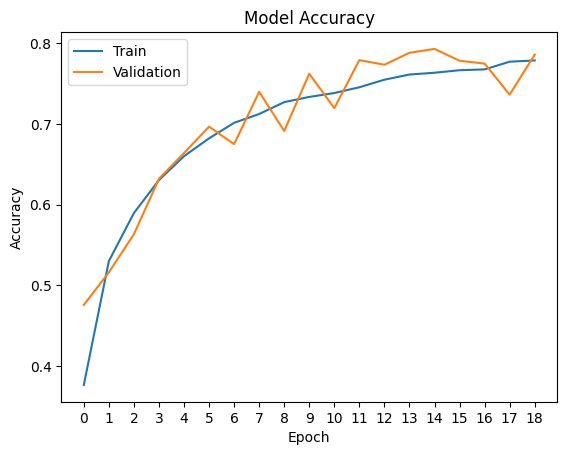

In [34]:
plt.plot(history4.history['accuracy'])
plt.plot(history4.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(range(len(history4.history['loss'])))
plt.legend(['Train', 'Validation'])

plt.show()

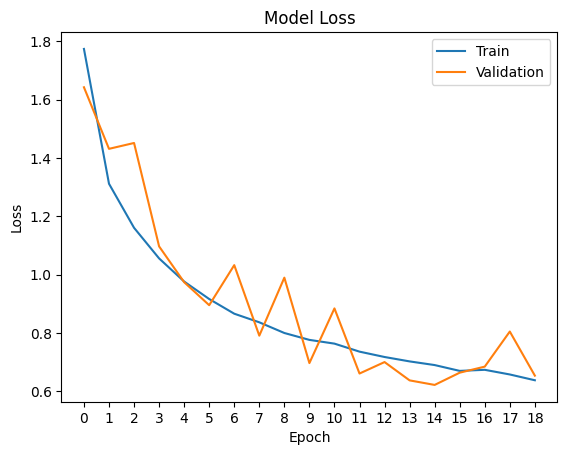

In [35]:
plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xticks(range(len(history4.history['loss'])))
plt.legend(['Train', 'Validation'])

plt.show()

In [36]:
test_loss, test_acc =model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7833 - loss: 0.6514
Test Accuracy: 0.78329998254776
Test loss: 0.6513689756393433


In [38]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


In [39]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

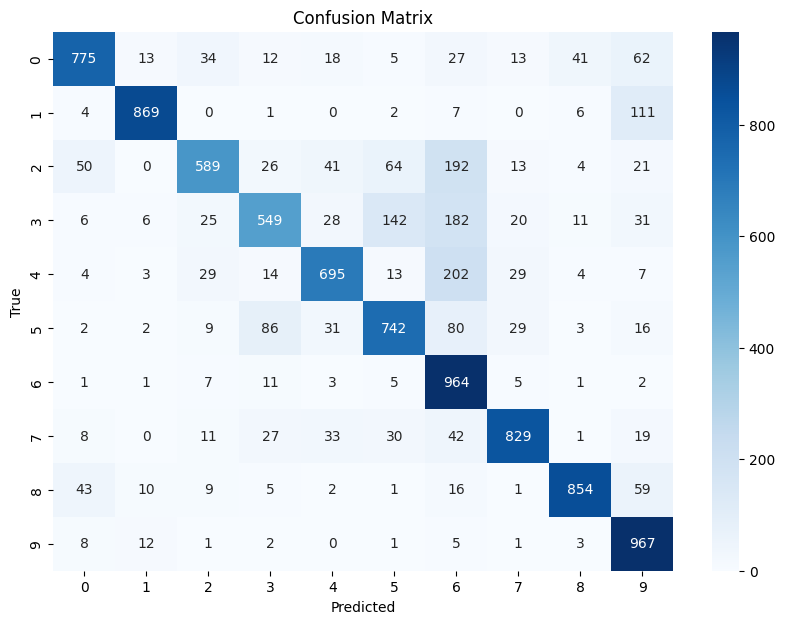

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1000
           1       0.95      0.87      0.91      1000
           2       0.82      0.59      0.69      1000
           3       0.75      0.55      0.63      1000
           4       0.82      0.69      0.75      1000
           5       0.74      0.74      0.74      1000
           6       0.56      0.96      0.71      1000
           7       0.88      0.83      0.85      1000
           8       0.92      0.85      0.89      1000
           9       0.75      0.97      0.84      1000

    accuracy                           0.78     10000
   macro avg       0.80      0.78      0.78     10000
weighted avg       0.80      0.78      0.78     10000

